In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
import math 
import sklearn.metrics
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.pipeline import Pipeline

In [5]:
df = pd.read_excel('Data IoTMLCQ.xlsx', engine='openpyxl')

In [7]:
df.head()

,id,temperatura,oxigeno,ph,turbidez,hour,day,month,temperatura_scaled,oxigeno_scaled
0,49,1.001750,0.089269,0.937644,-0.008761,19,17,1,27.041814,7.968205
1,55,1.044218,0.621644,0.936319,-0.043164,19,24,1,27.330717,8.190253
2,88,0.981081,0.234554,0.997134,0.027833,20,25,1,26.901205,8.028802
3,106,0.990495,-0.715270,0.946473,0.017791,20,27,1,26.965247,7.632639
4,113,1.031420,-0.611011,0.906770,0.006865,20,5,1,27.243652,7.676124


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 37284 entries, 0 to 37283
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   id                  37284 non-null  int64  
 1   temperatura         37284 non-null  float64
 2   oxigeno             37284 non-null  float64
 3   ph                  37284 non-null  float64
 4   turbidez            37284 non-null  float64
 5   hour                37284 non-null  int64  
 6   day                 37284 non-null  int64  
 7   month               37284 non-null  int64  
 8   temperatura_scaled  37284 non-null  float64
 9   oxigeno_scaled      37284 non-null  float64
dtypes: float64(6), int64(4)
memory usage: 2.8 MB


In [11]:
df.describe()

,id,temperatura,oxigeno,ph,turbidez,hour,day,month,temperatura_scaled,oxigeno_scaled
count,37284.000000,37284.000000,37284.000000,37284.000000,37284.000000,37284.000000,37284.000000,37284.000000,37284.000000,37284.000000
mean,5500.593177,0.988746,0.575191,0.427018,0.258958,9.598487,14.475164,3.500000,26.953352,8.170878
std,1823.441788,0.029668,0.510436,0.104145,0.209742,8.372377,8.097868,1.707848,0.201827,0.212898
min,49.000000,-0.033383,-1.512791,-0.004902,-0.069739,0.000000,1.000000,1.000000,20.000000,7.300000
25%,3959.000000,0.975692,0.231033,0.341596,0.123425,1.000000,7.000000,2.000000,26.864546,8.027333
50%,5514.500000,0.989196,0.576801,0.430090,0.178818,11.000000,14.000000,3.500000,26.956412,8.171550
75%,7068.000000,1.002740,0.918596,0.501549,0.435414,16.000000,22.000000,5.000000,27.048547,8.314109
max,8621.000000,1.069102,2.563060,1.042991,1.020229,23.000000,28.000000,6.000000,27.500000,9.000000


In [13]:
df.describe

<bound method NDFrame.describe of          id  temperatura   oxigeno        ph  turbidez  hour  day  month  \
0        49     1.001750  0.089269  0.937644 -0.008761    19   17      1   
1        55     1.044218  0.621644  0.936319 -0.043164    19   24      1   
2        88     0.981081  0.234554  0.997134  0.027833    20   25      1   
3       106     0.990495 -0.715270  0.946473  0.017791    20   27      1   
4       113     1.031420 -0.611011  0.906770  0.006865    20    5      1   
...     ...          ...       ...       ...       ...   ...  ...    ...   
37279  8617     0.956021  0.194102  0.446188  0.231352     1    4      6   
37280  8618     0.963806  0.475878  0.487667  0.203146     1   14      6   
37281  8619     0.967025 -0.095043  0.391965  0.212166     1    7      6   
37282  8620     0.980226  0.045029  0.466114  0.188222     1   15      6   
37283  8621     0.974306  0.596131  0.436985  0.192705     1   12      6   

       temperatura_scaled  oxigeno_scaled  
0        

In [29]:
df.rename(columns= {'temperatura':'temperature', 'oxigeno':'oxygen', 'turbidez':'turbid',
'oxigeno_scaled':'oxygen_scaled', 'temperatura_scaled':'temperature_scaled'}, inplace=True)

In [31]:
df.head(5)

,id,temperature,oxygen,ph,turbid,hour,day,month,temperature_scaled,oxygen_scaled
0,49,1.001750,0.089269,0.937644,-0.008761,19,17,1,27.041814,7.968205
1,55,1.044218,0.621644,0.936319,-0.043164,19,24,1,27.330717,8.190253
2,88,0.981081,0.234554,0.997134,0.027833,20,25,1,26.901205,8.028802
3,106,0.990495,-0.715270,0.946473,0.017791,20,27,1,26.965247,7.632639
4,113,1.031420,-0.611011,0.906770,0.006865,20,5,1,27.243652,7.676124


<Axes: >

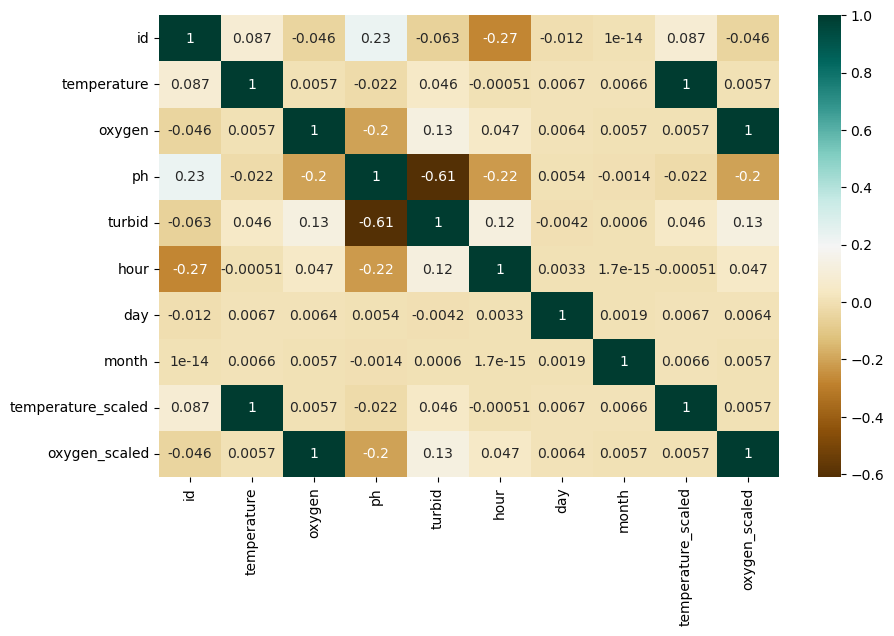

In [37]:
plt.figure(figsize = (10,6))
sns.heatmap(df.corr(),annot = True, cmap = 'BrBG')

In [41]:
#to mitigate the issue of multicollinearity we drop 2 columns as they are highly correlated with the original
df.drop(['temperature', 'oxygen'], inplace = True, axis = 1)
df.head()


,id,ph,turbid,hour,day,month,temperature_scaled,oxygen_scaled
0,49,0.937644,-0.008761,19,17,1,27.041814,7.968205
1,55,0.936319,-0.043164,19,24,1,27.330717,8.190253
2,88,0.997134,0.027833,20,25,1,26.901205,8.028802
3,106,0.946473,0.017791,20,27,1,26.965247,7.632639
4,113,0.906770,0.006865,20,5,1,27.243652,7.676124


In [51]:
Y = df['oxygen_scaled']
X = df.drop('oxygen_scaled', axis=1)
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size = 0.20)

In [57]:
#The linear regression model approximates the relationship between the input and target variables by finding the line that best fits the data points.
model = LinearRegression()
model.fit(X_train, Y_train)
pred = model.predict(X_test)
print(pred)

[8.12004782 8.12904184 8.21064155 ... 8.16783859 8.17163023 8.13284359]


In [59]:
mse = sklearn.metrics.mean_squared_error(Y_test, pred)
rmse = math.sqrt(mse)
print(rmse)

0.2050725766060464


In [61]:
model_2 = RandomForestRegressor(n_estimators = 200, max_depth = 15)
model_2.fit(X_train, Y_train)
pred = model_2.predict(X_test)
mse = sklearn.metrics.mean_squared_error(Y_test, pred)
rmse = math.sqrt(mse)
rmse

0.205910493296663

In [65]:
pipeline = Pipeline(steps = [
('model',model_2)
])

model = pipeline.fit(X_train, Y_train)
predictions = pipeline.predict(X_test)
print(math.sqrt(sklearn.metrics.mean_squared_error(Y_test, predictions)))

0.2059302966206923


In [69]:
!pip install xgboost

   ---------------------------------------- 0.0/150.0 MB ? eta -:--:--
   ---------------------------------------- 0.0/150.0 MB ? eta -:--:--
   ---------------------------------------- 0.0/150.0 MB ? eta -:--:--
   ---------------------------------------- 0.0/150.0 MB ? eta -:--:--
   ---------------------------------------- 0.3/150.0 MB ? eta -:--:--
   ---------------------------------------- 0.3/150.0 MB ? eta -:--:--
   ---------------------------------------- 0.3/150.0 MB ? eta -:--:--
   ---------------------------------------- 0.3/150.0 MB ? eta -:--:--
   ---------------------------------------- 0.5/150.0 MB 284.3 kB/s eta 0:08:46
   ---------------------------------------- 0.5/150.0 MB 284.3 kB/s eta 0:08:46
   ---------------------------------------- 0.8/150.0 MB 377.2 kB/s eta 0:06:36
   ---------------------------------------- 0.8/150.0 MB 377.2 kB/s eta 0:06:36
   ---------------------------------------- 0.8/150.0 MB 377.2 kB/s eta 0:06:36
   -----------------------------

In [71]:
import sklearn
from sklearn.ensemble import GradientBoostingRegressor
from xgboost import XGBRegressor

# Define models
gb_model = GradientBoostingRegressor(n_estimators=200, max_depth=5)
xgb_model = XGBRegressor(n_estimators=200, max_depth=5, learning_rate=0.1)

# Train models
gb_model.fit(X_train, Y_train)
xgb_model.fit(X_train, Y_train)

# Predict on test data
gb_pred = gb_model.predict(X_test)
xgb_pred = xgb_model.predict(X_test)

# Calculate RMSE for both models
gb_mse = sklearn.metrics.mean_squared_error(Y_test, gb_pred)
xgb_mse = sklearn.metrics.mean_squared_error(Y_test, xgb_pred)

gb_rmse = math.sqrt(gb_mse)
xgb_rmse = math.sqrt(xgb_mse)

# Print RMSE scores
print(f"Gradient Boosting RMSE: {gb_rmse}")
print(f"XGBoost RMSE: {xgb_rmse}")

Gradient Boosting RMSE: 0.20686269054378667
XGBoost RMSE: 0.20697558025421064
